# Lecture 18 — Generative Adversarial Networks in Code

**CMU 10-414/714, Deep Learning Systems (lecture by Tianqi Chen)**
Companion notebook · Sangram Lembe

A GAN trains two networks against each other. The **generator** turns random noise into fake data;
the **discriminator** tries to tell fake from real. The generator improves by fooling the discriminator,
the discriminator by not being fooled.

Following the lecture, the target is a 2-D Gaussian and the generator is a single linear layer — simple
enough that we can check *exactly* what it learned. Built on the needle-style autodiff engine from
earlier lectures, with nothing else underneath.

In [1]:
import numpy as np

class Tensor:
    """A needle-style tensor: data plus the op and inputs that produced it."""

    def __init__(self, array, requires_grad=True):
        self._init(None, [], np.asarray(array, dtype=np.float64), requires_grad)

    def _init(self, op, inputs, cached, requires_grad):
        self.op, self.inputs = op, list(inputs)
        self.cached, self.requires_grad, self.grad = cached, requires_grad, None

    @classmethod
    def make_const(cls, array):
        """A leaf with no history - what detach() returns."""
        t = Tensor.__new__(Tensor)
        t._init(None, [], array, False)
        return t

    @staticmethod
    def make_from_op(op, inputs):
        out = op.compute(*[i.cached for i in inputs])
        if not any(i.requires_grad for i in inputs):
            return Tensor.make_const(out)        # nothing needs a gradient: no graph
        t = Tensor.__new__(Tensor)
        t._init(op, inputs, out, True)
        return t

    # .data is a detached view that SHARES memory; assigning to it updates in place
    @property
    def data(self):
        return Tensor.make_const(self.cached)
    @data.setter
    def data(self, value):
        self.cached = value.cached if isinstance(value, Tensor) else np.asarray(value)

    def detach(self):  return self.data
    def numpy(self):   return self.cached
    shape = property(lambda s: s.cached.shape)
    def __repr__(self):
        return f"Tensor({np.array2string(self.cached, precision=4)}, op={type(self.op).__name__ if self.op else None})"

    def __add__(s, o):  return EAdd()(s, o) if isinstance(o, Tensor) else AddS(o)(s)
    def __mul__(s, o):  return EMul()(s, o) if isinstance(o, Tensor) else MulS(o)(s)
    def __neg__(s):     return MulS(-1.0)(s)
    def __sub__(s, o):  return s + (-o)
    def __rsub__(s, o): return (-s) + o
    def __pow__(s, c):  return PowS(c)(s)
    def __truediv__(s, o):
        return s * (o ** -1.0) if isinstance(o, Tensor) else MulS(1.0 / o)(s)
    def __matmul__(s, o): return MatMul()(s, o)
    __radd__, __rmul__ = __add__, __mul__

    def backward(self):
        backprop(self, Tensor.make_const(np.ones_like(self.cached)))


class Op:
    def __call__(self, *ins):
        return Tensor.make_from_op(self, ins)
    def grads(self, g, node):
        r = self.gradient(g, node)
        return r if isinstance(r, tuple) else (r,)

class EAdd(Op):
    def compute(s, a, b): return a + b
    def gradient(s, g, n): return g, g
class AddS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a + s.c
    def gradient(s, g, n): return g
class EMul(Op):
    def compute(s, a, b): return a * b
    def gradient(s, g, n): return g * n.inputs[1], g * n.inputs[0]
class MulS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a * s.c
    def gradient(s, g, n): return g * s.c
class PowS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a ** s.c
    def gradient(s, g, n): return g * (n.inputs[0] ** (s.c - 1)) * s.c
class MatMul(Op):
    def compute(s, a, b): return a @ b
    def gradient(s, g, n):
        return g @ transpose(n.inputs[1]), transpose(n.inputs[0]) @ g
class Transpose(Op):
    def compute(s, a): return a.T
    def gradient(s, g, n): return transpose(g)
class Reshape(Op):
    def __init__(s, shape): s.shape = shape
    def compute(s, a): return a.reshape(s.shape)
    def gradient(s, g, n): return reshape(g, n.inputs[0].shape)
class BroadcastTo(Op):
    def __init__(s, shape): s.shape = shape
    def compute(s, a): return np.broadcast_to(a, s.shape).copy()
    def gradient(s, g, n):                        # broadcast forward = sum backward
        ins = n.inputs[0].shape
        pad = len(s.shape) - len(ins)
        axes = tuple(range(pad)) + tuple(pad + i for i, d in enumerate(ins)
                                         if d == 1 and s.shape[pad + i] != 1)
        return reshape(summation(g, axes) if axes else g, ins)
class Summation(Op):
    def __init__(s, axes=None):
        s.axes = (axes,) if isinstance(axes, int) else axes
    def compute(s, a): return a.sum(axis=s.axes)
    def gradient(s, g, n):
        ins = n.inputs[0].shape
        ax = range(len(ins)) if s.axes is None else s.axes
        keep = tuple(1 if i in ax else d for i, d in enumerate(ins))
        return broadcast_to(reshape(g, keep), ins)
class ReLUOp(Op):
    def compute(s, a): return np.maximum(0, a)
    def gradient(s, g, n):
        return g * Tensor.make_const((n.inputs[0].cached > 0) * 1.0)
class Exp(Op):
    def compute(s, a): return np.exp(a)
    def gradient(s, g, n): return g * exp(n.inputs[0])
class LogSumExp(Op):
    """Stable log-sum-exp over axis 1: subtract the row max first."""
    def compute(s, a):
        m = a.max(1, keepdims=True)
        return (np.log(np.exp(a - m).sum(1, keepdims=True)) + m)[:, 0]
    def gradient(s, g, n):
        z = n.inputs[0]
        sm = exp(z - broadcast_to(reshape(n, (z.shape[0], 1)), z.shape))
        return broadcast_to(reshape(g, (z.shape[0], 1)), z.shape) * sm

transpose    = lambda a: Transpose()(a)
reshape      = lambda a, s: Reshape(s)(a)
broadcast_to = lambda a, s: BroadcastTo(s)(a)
summation    = lambda a, axes=None: Summation(axes)(a)
relu         = lambda a: ReLUOp()(a)
exp          = lambda a: Exp()(a)
logsumexp    = lambda a: LogSumExp()(a)

def topo_sort(root):
    """Post-order DFS, iterative so that very deep graphs cannot overflow the stack."""
    order, seen, stack = [], set(), [(root, False)]
    while stack:
        node, done = stack.pop()
        if done:
            order.append(node)
            continue
        if id(node) in seen:
            continue
        seen.add(id(node))
        stack.append((node, True))
        for i in node.inputs:
            if id(i) not in seen:
                stack.append((i, False))
    return order

def backprop(out, seed):
    """Reverse-mode AD: walk reverse topological order, summing partial adjoints."""
    parts = {id(out): [seed]}
    for node in reversed(topo_sort(out)):
        if id(node) not in parts: continue
        g = parts[id(node)][0]
        for extra in parts[id(node)][1:]:
            g = g + extra
        node.grad = g
        if node.op is not None:
            for inp, p in zip(node.inputs, node.op.grads(g, node)):
                if inp.requires_grad:
                    parts.setdefault(id(inp), []).append(p)

def numeric_grad(f, param, eps=1e-6):
    """Two-sided finite differences of scalar f() w.r.t. every entry of param."""
    g = np.zeros_like(param.cached)
    for idx in np.ndindex(*param.cached.shape):
        old = param.cached[idx]
        param.cached[idx] = old + eps; a = float(f().cached)
        param.cached[idx] = old - eps; b = float(f().cached)
        param.cached[idx] = old
        g[idx] = (a - b) / (2 * eps)
    return g



print('engine ready')

engine ready


## 1. Building blocks

`Linear`, `ReLU`, `Sequential`, a softmax loss, and Adam. With two classes, the softmax loss *is*
binary cross-entropy — the lecture uses it for exactly that reason.

In [2]:
class Parameter(Tensor):
    pass

class Module:
    def parameters(self):
        out = []
        for v in self.__dict__.values():
            if isinstance(v, Parameter): out.append(v)
            elif isinstance(v, Module): out += v.parameters()
            elif isinstance(v, (list, tuple)):
                for m in v:
                    if isinstance(m, Module): out += m.parameters()
        return out
    def __call__(self, *a): return self.forward(*a)

class Linear(Module):
    def __init__(self, n_in, n_out, rng):
        self.W = Parameter(rng.normal(0, np.sqrt(1.0 / n_in), (n_in, n_out)))
        self.b = Parameter(np.zeros((1, n_out)))
    def forward(self, x):
        out = x @ self.W
        return out + broadcast_to(self.b, out.shape)

class ReLU(Module):
    def forward(self, x): return relu(x)

class Sequential(Module):
    def __init__(self, *mods): self.mods = list(mods)
    def forward(self, x):
        for m in self.mods: x = m(x)
        return x

class SoftmaxLoss(Module):
    """Two classes here, so this is binary cross-entropy."""
    def forward(self, logits, labels):
        B = logits.shape[0]
        Y = Tensor.make_const(np.eye(logits.shape[1])[labels])
        return summation(logsumexp(logits) - summation(logits * Y, 1)) / B

class Adam:
    def __init__(self, params, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps, self.t = params, lr, b1, b2, eps, 0
        self.m = [np.zeros_like(p.cached) for p in params]
        self.v = [np.zeros_like(p.cached) for p in params]
    def reset_grad(self):
        for p in self.params: p.grad = None
    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            if p.grad is None: continue
            g = p.grad.cached
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * g * g
            mh, vh = self.m[i] / (1 - self.b1 ** self.t), self.v[i] / (1 - self.b2 ** self.t)
            p.data = p.cached - self.lr * mh / (np.sqrt(vh) + self.eps)

print('modules ready')

modules ready


## 2. The real data

Sample standard Gaussian noise $z$ and transform it: $x = zA + \mu$. The result is a Gaussian with mean
$\mu$ and covariance $A^{\mathsf T}A$ — a tilted ellipse.

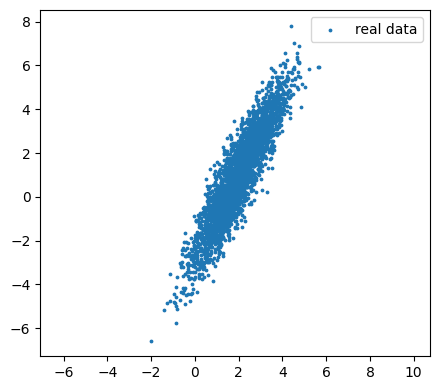

covariance A^T A =
 [[1.04 1.9 ]
 [1.9  4.25]]


In [3]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
A = np.array([[1.0, 2.0], [-0.2, 0.5]])
mu = np.array([2.0, 1.0])
data = rng.normal(0, 1, (3200, 2)) @ A + mu

plt.figure(figsize=(4.5, 4))
plt.scatter(data[:, 0], data[:, 1], s=3, c="tab:blue", label="real data")
plt.legend(); plt.axis("equal"); plt.tight_layout(); plt.show()
print("covariance A^T A =\n", A.T @ A)

## 3. The generator

A single linear layer: $G(z) = zW + b$. That can represent the target exactly, which is what makes the
result checkable later.

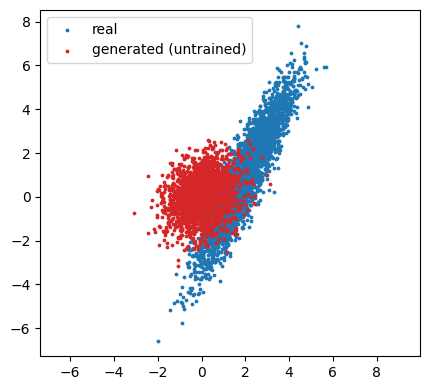

In [4]:
G = Linear(2, 2, rng)

def sample_G(G, n):
    z = Tensor(rng.normal(0, 1, (n, 2)), requires_grad=False)
    return G(z).cached

fake_init = sample_G(G, 2000)
plt.figure(figsize=(4.5, 4))
plt.scatter(data[:, 0], data[:, 1], s=3, c="tab:blue", label="real")
plt.scatter(fake_init[:, 0], fake_init[:, 1], s=3, c="tab:red", label="generated (untrained)")
plt.legend(); plt.axis("equal"); plt.tight_layout(); plt.show()

## 4. The discriminator

A small classifier, 2 → 20 → 10 → 2, exactly as in the lecture. Class 1 means "real", class 0 "fake".

In [5]:
D = Sequential(Linear(2, 20, rng), ReLU(), Linear(20, 10, rng), ReLU(), Linear(10, 2, rng))
loss_D = SoftmaxLoss()
opt_G = Adam(G.parameters(), lr=0.01)
opt_D = Adam(D.parameters(), lr=0.01)
print("generator parameters    :", sum(p.cached.size for p in G.parameters()))
print("discriminator parameters:", sum(p.cached.size for p in D.parameters()))

generator parameters    : 6
discriminator parameters: 292


## 5. The two update steps

**Generator step.** Generate fakes, ask the discriminator about them, and compute the loss *as if they
were real* (label 1). Minimising that loss pushes the generator towards fooling the discriminator. Only
the generator's optimizer steps, even though gradients flow through the discriminator to get there.

**Discriminator step.** Fakes should be classified 0, real data 1. The fakes are `detach`ed: here we only
want to train the discriminator, so there is no reason to send gradients back into the generator.

In [6]:
def update_G(Z, G, D, loss_D, opt_G):
    opt_G.reset_grad()
    x_fake = G(Z)
    y_fake = D(x_fake)
    ones = np.ones(Z.shape[0], dtype=int)          # pretend the fakes are real
    loss = loss_D(y_fake, ones)
    loss.backward()
    opt_G.step()                                   # only the GENERATOR moves
    return float(loss.cached)

def update_D(X, Z, G, D, loss_D, opt_D):
    opt_D.reset_grad()
    x_fake = G(Z).detach()                         # no gradient back into G
    B = Z.shape[0]
    loss = loss_D(D(x_fake), np.zeros(B, dtype=int)) + loss_D(D(X), np.ones(B, dtype=int))
    loss.backward()
    opt_D.step()                                   # only the DISCRIMINATOR moves
    return float(loss.cached)

### What `detach` actually saves

Run the discriminator's loss with and without `detach`, and check whether the generator's weights
received a gradient:

In [7]:
Z0 = Tensor(rng.normal(0, 1, (8, 2)), requires_grad=False)
X0 = Tensor(data[:8], requires_grad=False)
for use_detach in (False, True):
    for p in G.parameters() + D.parameters(): p.grad = None
    fake = G(Z0).detach() if use_detach else G(Z0)
    loss = loss_D(D(fake), np.zeros(8, dtype=int)) + loss_D(D(X0), np.ones(8, dtype=int))
    loss.backward()
    print(f"detach={str(use_detach):<5}  generator got a gradient: {G.W.grad is not None}"
          f"   graph nodes behind the loss: {len(topo_sort(loss))}")

detach=False  generator got a gradient: True   graph nodes behind the loss: 52
detach=True   generator got a gradient: False   graph nodes behind the loss: 47


Without `detach` the backward pass also runs through the generator — work that is thrown away, since the
discriminator step never updates it.

## 6. Training: alternate the two steps

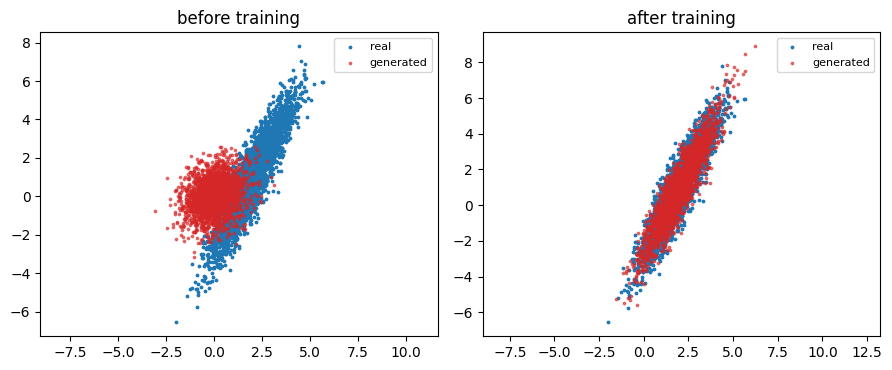

In [8]:
def train_gan(data, G, D, opt_G, opt_D, batch=32, iters=2000):
    hist = []
    for it in range(iters):
        s = (it * batch) % len(data)
        X = Tensor(data[s:s + batch], requires_grad=False)
        Z = Tensor(rng.normal(0, 1, (batch, 2)), requires_grad=False)
        lg = update_G(Z, G, D, loss_D, opt_G)
        ld = update_D(X, Z, G, D, loss_D, opt_D)
        if it % 100 == 0:
            p_real = np.exp(D(X).cached); p_real = p_real[:, 1] / p_real.sum(1)
            hist.append((it, lg, ld, p_real.mean()))
    return hist

hist = train_gan(data, G, D, opt_G, opt_D)
fake_trained = sample_G(G, 2000)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a_, f, t in [(ax[0], fake_init, "before training"), (ax[1], fake_trained, "after training")]:
    a_.scatter(data[:, 0], data[:, 1], s=3, c="tab:blue", label="real")
    a_.scatter(f[:, 0], f[:, 1], s=3, c="tab:red", alpha=0.6, label="generated")
    a_.set_title(t); a_.axis("equal"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
print(f"{'iter':>6}{'G loss':>9}{'D loss':>9}{'D says real is real':>22}")
for it, lg, ld, pr in hist[::4]:
    print(f"{it:>6}{lg:>9.3f}{ld:>9.3f}{pr:>22.2f}")

  iter   G loss   D loss   D says real is real
     0    0.688    1.195                  0.70
   400    0.740    1.397                  0.51
   800    0.725    1.356                  0.51
  1200    0.698    1.377                  0.50
  1600    0.693    1.387                  0.50


As the generator improves, the discriminator loses its edge: its confidence that real data is real drifts
towards 0.5, a coin flip — the sign that the two distributions have become hard to tell apart.

## 7. What did the generator learn?

The generator is $zW + b$, so its output has mean $b$ and covariance $W^{\mathsf T}W$. Compare with the
truth:

In [10]:
W, b = G.W.cached, G.b.cached[0]
print("true mean mu     :", mu, "    learned b:", np.round(b, 2))
print("true  A^T A      :\n", np.round(A.T @ A, 2))
print("learned W^T W    :\n", np.round(W.T @ W, 2))
print("\nbut A itself    :\n", A, "\nand learned W    :\n", np.round(W, 2))

true mean mu     : [2. 1.]     learned b: [1.97 0.95]
true  A^T A      :
 [[1.04 1.9 ]
 [1.9  4.25]]
learned W^T W    :
 [[1.17 2.08]
 [2.08 4.33]]

but A itself    :
 [[ 1.   2. ]
 [-0.2  0.5]] 
and learned W    :
 [[ 0.45  0.06]
 [-0.98 -2.08]]


Mean and covariance match closely — yet $W$ looks nothing like $A$. That is not a failure. Many different
matrices produce the same covariance: rotate $A$ by any rotation $Q$ and
$(QA)^{\mathsf T}(QA) = A^{\mathsf T}Q^{\mathsf T}QA = A^{\mathsf T}A$. The generator only has to match the
*distribution*, and every one of those matrices does.

In [11]:
theta = 0.7
Q = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
QA = Q @ A
print("QA =\n", np.round(QA, 2))
print("(QA)^T (QA) equals A^T A:", np.allclose(QA.T @ QA, A.T @ A))

QA =
 [[0.89 1.21]
 [0.49 1.67]]
(QA)^T (QA) equals A^T A: True


## 8. A modular GAN loss

The alternating loop is awkward to compose with other code. The lecture's fix: hide the discriminator
update *inside* a loss module. Each call first trains the discriminator one step, then returns the loss
the generator should minimise. From outside, training looks like ordinary supervised learning.

In [12]:
class GANLoss:
    def __init__(self, model_D, opt_D):
        self.model_D, self.opt_D, self.loss_D = model_D, opt_D, SoftmaxLoss()

    def _update_D(self, x_fake, x_real):
        self.opt_D.reset_grad()
        B = x_fake.shape[0]
        loss = self.loss_D(self.model_D(x_fake.detach()), np.zeros(B, dtype=int)) + \
               self.loss_D(self.model_D(x_real), np.ones(B, dtype=int))
        loss.backward()
        self.opt_D.step()

    def __call__(self, x_fake, x_real):
        self._update_D(x_fake, x_real)                        # the hidden step
        y_fake = self.model_D(x_fake)
        return self.loss_D(y_fake, np.ones(x_fake.shape[0], dtype=int))

G2 = Linear(2, 2, rng)
D2 = Sequential(Linear(2, 20, rng), ReLU(), Linear(20, 10, rng), ReLU(), Linear(10, 2, rng))
opt_G2 = Adam(G2.parameters(), lr=0.01)
gan_loss = GANLoss(D2, Adam(D2.parameters(), lr=0.01))

for it in range(2000):                                       # looks like supervised training
    opt_G2.reset_grad()
    s = (it * 32) % len(data)
    X = Tensor(data[s:s + 32], requires_grad=False)
    Z = Tensor(rng.normal(0, 1, (32, 2)), requires_grad=False)
    loss = gan_loss(G2(Z), X)
    loss.backward()
    opt_G2.step()

W2, b2 = G2.W.cached, G2.b.cached[0]
print("modular GAN loss -> learned mean:", np.round(b2, 2))
print("learned covariance:\n", np.round(W2.T @ W2, 2))

modular GAN loss -> learned mean: [1.99 0.97]
learned covariance:
 [[0.95 1.75]
 [1.75 3.45]]


Same result, cleaner structure. Because a GAN loss is now just a loss, it can be combined with others —
the lecture's example is CycleGAN, which uses several adversarial losses at once.

## Summary

- The generator maps noise to data; the discriminator classifies real versus fake; the two are updated
  in turn.
- Generator step: label the fakes "real" and step only the generator. Discriminator step: fakes 0, real 1,
  with the fakes `detach`ed so no work is wasted on the generator.
- The linear generator learned mean $\approx \mu$ and covariance $W^{\mathsf T}W \approx A^{\mathsf T}A$,
  while $W \ne A$ — many matrices share one covariance.
- Wrapping the discriminator update inside `GANLoss` makes GAN training look like supervised training.